# Clasificación de textos por década — Parte 1: Machine Learning Clásico

**Competencia:** Aprendizaje de Máquina 2026-10  
**Tarea:** Predecir la **década** (primeros 3 dígitos del año) en que fue escrito un párrafo de texto histórico en español.  
**Clases:** Décadas del `150` al `188` (años 1500–1889), **39 clases** en total.  
**Restricción:** Únicamente modelos de `scikit-learn`, sin redes neuronales ni transformers.

## 1. Importaciones

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

SEED = 42
np.random.seed(SEED)

## 2. Carga de datos

In [37]:
df_train = pd.read_csv('train.csv')
df_eval  = pd.read_csv('eval.csv')

print(f"Train: {df_train.shape}")
print(f"Eval:  {df_eval.shape}")
df_train.head(3)

Train: (31403, 2)
Eval:  (3490, 2)


,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157


## 3. Análisis Exploratorio (EDA)

Décadas únicas : 39
Rango          : 150 – 188
Ejemplos/clase : min=754, max=848, media=805


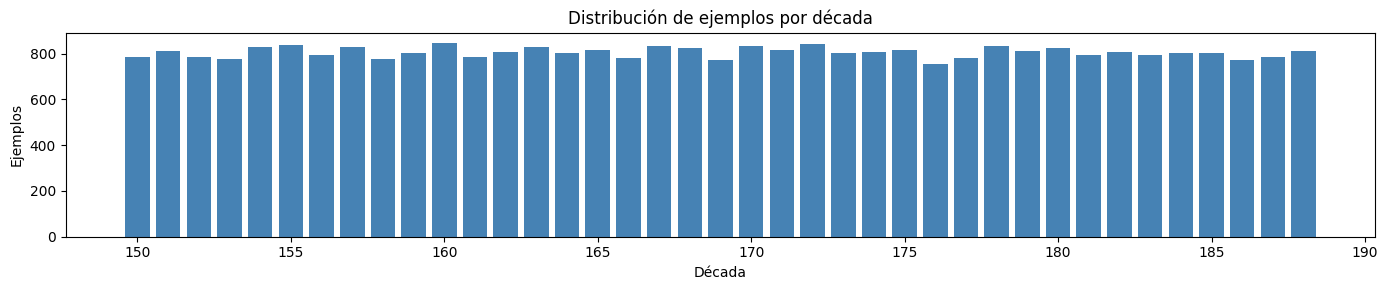

In [38]:
vc = df_train['decade'].value_counts().sort_index()

print(f"Décadas únicas : {df_train['decade'].nunique()}")
print(f"Rango          : {df_train['decade'].min()} – {df_train['decade'].max()}")
print(f"Ejemplos/clase : min={vc.min()}, max={vc.max()}, media={vc.mean():.0f}")

plt.figure(figsize=(14, 3))
plt.bar(vc.index, vc.values, color='steelblue')
plt.xlabel('Década'); plt.ylabel('Ejemplos')
plt.title('Distribución de ejemplos por década')
plt.tight_layout(); plt.show()

count    31403.000000
mean       520.568290
std        530.947792
min        120.000000
25%        182.000000
50%        315.000000
75%        643.000000
max       7418.000000
Name: text, dtype: float64


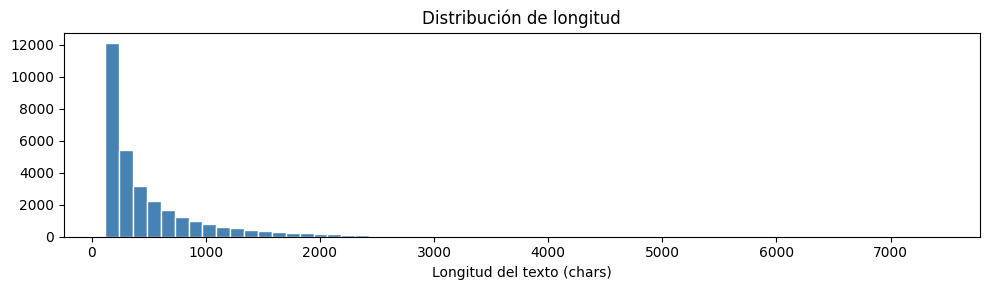

In [39]:
# Longitud de los textos
lens = df_train['text'].str.len()
print(lens.describe())

plt.figure(figsize=(10, 3))
plt.hist(lens, bins=60, color='steelblue', edgecolor='white')
plt.xlabel('Longitud del texto (chars)'); plt.title('Distribución de longitud')
plt.tight_layout(); plt.show()

In [40]:
# Muestra de textos por siglo
for decade in [150, 160, 170, 180, 188]:
    sample = df_train[df_train['decade'] == decade]['text'].iloc[0][:120]
    print(f"Década {decade}: {repr(sample)}\n")

Década 150: 'efiotnl fiiT’e^ pt\\»tf)e 4 trCe et lleene.^^ta^ \n41 tT»íi A*e(leee A(ittc(«t>iieii|l>le iié <oii|ette \n*iW íléiW^* temer'

Década 160: "blar enla oracion de pereza, i floxedad ,i por eltar medio: \ndormido», ifi hablara,fe defpertara,i'avivara para la orar "

Década 170: '\n2y. Mas fi no mieote el oido: \nReyna. Palos fuenan. Rey. Paños andan \nSalen por laswejimas puertas que fe entraromg \nel'

Década 180: '\n(87) \nobligación  que  las  Ordenanzas  imponen  al  Director \ngeneral  de  la  Armada  sobre  el  zelar  que  se  mejo'

Década 188: '\n—  302  — \ncapaz  el  corazón  corrompido  del  hombre  inculto  é  iluso.  Y  no \ndeja  de  ser  digno  de  notarse:  '



## 4. Preprocesamiento del texto

Se aplica una limpieza **mínima** para preservar las señales ortográficas históricas que cambiaron entre los siglos XVI y XIX (e.g. uso de la 's' larga escrita como 'f', cambios en 'b/v', ortografía variante, etc.). Esas características son la clave para la clasificación temporal.

In [41]:
def preprocess(text: str) -> str:
    """Limpieza mínima: colapsa saltos de línea y convierte a minúsculas."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = text.lower()
    return re.sub(r' +', ' ', text).strip()

df_train['clean_text'] = df_train['text'].apply(preprocess)
df_eval['clean_text']  = df_eval['text'].apply(preprocess)

print("Original:")
print(repr(df_train['text'].iloc[0][:200]))
print("\nLimpio:")
print(repr(df_train['clean_text'].iloc[0][:200]))

Original:
'\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \nnes parece que aísilte, O ayuda Calsiodoro \nlib,6.epuft.s 2.Donde * llama '

Limpio:
'honorarias ¡jubiladas. 57 dit.ad pontem de poreft.proreg.118,3, $.9.m.-70 pag.4.1. 3 ste ph.gratian. difcept.291, áqu len nes parece que aísilte, o ayuda calsiodoro lib,6.epuft.s 2.donde * llama oclos'


In [42]:
X_train = df_train['clean_text'].values
y_train = df_train['decade'].values
X_eval  = df_eval['clean_text'].values

print(f"Train: {len(X_train)} ejemplos | Eval: {len(X_eval)} ejemplos")

Train: 31403 ejemplos | Eval: 3490 ejemplos


## 5. Comparación de modelos

### Estrategia de representación

Se evalúan distintas configuraciones de TF-IDF + `LinearSVC`:

| Vectorizador | Diferencia | Propósito |
|---|---|---|
| `analyzer='word'` | N-gramas de palabras | Vocabulario de cada época |
| `analyzer='char_wb'` | N-gramas de caracteres (respeta límites de palabra) | Ortografía y morfología |
| `analyzer='char'` | N-gramas de caracteres (cruza límites de palabra) | Ortografía + contexto entre palabras |

**Hallazgo clave:** `char` (sin word-boundary) supera a `char_wb` y a la combinación con palabras. Al cruzar límites de palabras captura n-gramas como `" el "`, `"de "`, `" que"` que funcionan como señales estilísticas temporales, y es más robusto al ruido de OCR que los n-gramas de palabras completas.

In [43]:
# División hold-out estratificada (85% train / 15% val)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train
)
print(f"Train: {len(X_tr)} | Val: {len(X_val)}")

Train: 26692 | Val: 4711


In [ ]:
# Pipelines a comparar
pipelines = {
    # Baseline: Regresión Logística con palabras
    'LR  word(1-2)': Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1,2),
                                   max_features=100_000, sublinear_tf=True, min_df=2)),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, solver='saga',
                                    random_state=SEED, n_jobs=-1))
    ]),
    # Combinado word + char_wb
    'SVC word+char_wb C=1': Pipeline([
        ('features', FeatureUnion([
            ('word', TfidfVectorizer(analyzer='word', ngram_range=(1,2),
                                     max_features=100_000, sublinear_tf=True, min_df=2)),
            ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5),
                                     max_features=200_000, sublinear_tf=True, min_df=2)),
        ])),
        ('clf', LinearSVC(C=1.0, max_iter=3000, random_state=SEED))
    ]),
    # char_wb solo
    'SVC char_wb(2-5) C=1': Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5),
                                   max_features=200_000, sublinear_tf=True, min_df=2)),
        ('clf', LinearSVC(C=1.0, max_iter=3000, random_state=SEED))
    ]),
    # char sin word-boundary (cruza límites de palabra) — mejor configuración
    'SVC char(2-5) C=0.5': Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(2,5),
                                   max_features=300_000, sublinear_tf=True, min_df=2)),
        ('clf', LinearSVC(C=0.5, max_iter=3000, random_state=SEED))
    ]),
}

In [45]:
results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_tr, y_tr)
    acc = accuracy_score(y_val, pipe.predict(X_val))
    results[name] = acc
    print(f"{name:30s}  val_acc={acc:.4f}")

best_name = max(results, key=results.get)
print(f"\nMejor modelo: {best_name}  ({results[best_name]:.4f})")
print(f"Baseline aleatorio: {1/39:.4f}")

LR  word(1-2)                   val_acc=0.2169
SVC char_wb(2-5) C=1            val_acc=0.2738
SVC word+char C=1               val_acc=0.2641
SVC word+char C=0.5             val_acc=0.2702

Mejor modelo: SVC char_wb(2-5) C=1  (0.2738)
Baseline aleatorio: 0.0256


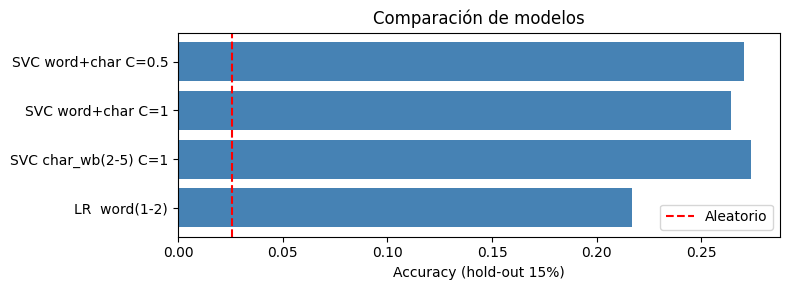

In [46]:
plt.figure(figsize=(8, 3))
bars = plt.barh(list(results.keys()), list(results.values()), color='steelblue')
plt.axvline(1/39, color='red', linestyle='--', label='Aleatorio')
plt.xlabel('Accuracy (hold-out 15%)')
plt.title('Comparación de modelos')
plt.legend(); plt.tight_layout(); plt.show()

## 6. Entrenamiento del modelo final

El mejor modelo es `SVC char(2-5) C=0.5` (`analyzer='char'`, sin word-boundary). Se reentrena con **todos los datos de entrenamiento**.

In [ ]:
# Mejor modelo: char(2-5) sin word-boundary + LinearSVC(C=0.5)
# analyzer='char' cruza límites de palabra → captura patrones estilísticos + ortográficos
best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char',
        ngram_range=(2, 5),
        max_features=300_000,
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', LinearSVC(C=0.5, max_iter=3000, random_state=SEED))
])

print("Entrenando modelo final con todos los datos...")
best_pipeline.fit(X_train, y_train)

train_acc = accuracy_score(y_train, best_pipeline.predict(X_train))
print(f"Train accuracy (referencia): {train_acc:.4f}")
print(f"Val   accuracy (hold-out):   {results.get('SVC char(2-5) C=0.5', 0):.4f}")

In [ ]:
# Reporte de clasificación sobre el hold-out
val_pred = pipelines[best_name].predict(X_val)   # usa el modelo ya entrenado en hold-out
print(classification_report(y_val, val_pred))

## 7. Análisis de errores

In [ ]:
# ¿Cuánto se equivoca el modelo en número de décadas?
errors = np.abs(y_val.astype(int) - val_pred.astype(int))
print("Distribución de error (décadas de diferencia):")
for k in range(6):
    pct = (errors == k).mean() * 100
    print(f"  |error| = {k}:  {pct:.1f}%")
print(f"  |error| ≥ 6:  {(errors >= 6).mean()*100:.1f}%")

plt.figure(figsize=(10, 3))
plt.hist(errors, bins=range(0, 40), color='steelblue', edgecolor='white')
plt.xlabel('|Década real − Década predicha|')
plt.ylabel('Ejemplos'); plt.title('Distribución del error en décadas')
plt.tight_layout(); plt.show()

## 8. Guardar el modelo

In [ ]:
joblib.dump(best_pipeline, 'modelo_parte1.joblib')
print("Modelo guardado en: modelo_parte1.joblib")

# Verificación
loaded = joblib.load('modelo_parte1.joblib')
check = loaded.predict(X_train[:5])
print(f"Predicciones (primeros 5): {check}")
print(f"Etiquetas reales:          {y_train[:5]}")

## 9. Generación del archivo de respuesta (submission)

In [ ]:
eval_pred  = best_pipeline.predict(X_eval)

submission = pd.DataFrame({
    'id':     df_eval['id'],
    'answer': eval_pred
})

submission.to_csv('submission.csv', index=False)
print(f"submission.csv generado: {len(submission)} predicciones")
print(f"Rango de décadas predichas: {eval_pred.min()} – {eval_pred.max()}")
print(f"Décadas únicas predichas:   {len(np.unique(eval_pred))}")
print()
print(submission.head(10).to_string(index=False))

In [ ]:
# Distribución de predicciones vs entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

vc_train = pd.Series(y_train).value_counts().sort_index()
vc_pred  = pd.Series(eval_pred).value_counts().sort_index()

axes[0].bar(vc_train.index, vc_train.values, color='steelblue')
axes[0].set_title('Distribución train'); axes[0].set_xlabel('Década')

axes[1].bar(vc_pred.index, vc_pred.values, color='coral')
axes[1].set_title('Predicciones (eval)'); axes[1].set_xlabel('Década')

plt.tight_layout(); plt.show()

## Resumen

| Componente | Detalle |
|---|---|
| **Preprocesamiento** | Colapso de saltos de línea + minúsculas (preserva ortografía histórica) |
| **Features** | TF-IDF `char` (sin word-boundary): 2–5 gramas, 300k features, `sublinear_tf=True` |
| **Modelo** | `LinearSVC(C=0.5)` — scikit-learn |
| **Por qué `char`** | Cruza límites de palabra → captura patrones estilísticos temporales + robusto a OCR |
| **Comparación (hold-out)** | char no-wb (0.279) > char_wb (0.274) > word+char (0.264) > word (0.217) |
| **Validación** | Hold-out estratificado 15% — acc≈0.279 en 39 clases (×10.9 sobre aleatorio) |
| **Modelo guardado** | `modelo_parte1.joblib` (joblib) |
| **Submission** | `submission.csv` (formato `id,answer`) |